# Day 4 is Exercise 4 — Sea Temperature vs Salmon Lice.
The goal is to investigate 
* whether warmer seawater is associated with higher adult female lice levels in the 2025 BarentsWatch data. 
* This is a relationship/correlation analysis, not proof that temperature causes lice levels to increase.

# The key scientific question will be:

* Are higher sea temperatures associated with higher adult female salmon lice levels in the 2025 observations?

# We will work mainly with:

* sea_temperature_c
* adult_female_lice
* week
* locality_id
* locality_name

# The Day 4 workflow will be:

* Keep rows where both temperature and adult female lice are available.
* Inspect the distributions and data coverage.
* Make a scatter plot: sea temperature vs adult female lice.
* Calculate a correlation coefficient.
* Look for outliers and understand whether a few extreme values are driving the relationship.
* Group temperature into ranges/bins and compare average lice levels.
* Optionally examine whether the relationship changes across the year.
* Save the final Day 4 figure and a small processed results table.

In [3]:
# Load the clean data sets
import pandas as pd
from pathlib import Path

clean_file = (
    Path.home() 
    /"Documents"
    /"Kazi_Academic"
    /"Projects"
    /"Aquaculture"
    /"fish-health-analytics"
    /"data"
    /"processed"
    /"barentswatch_lice_2025_clean.csv"
)
df = pd.read_csv(clean_file)
df. shape

/tmp/ipykernel_406134/719611192.py:16: DtypeWarning: Columns (0: weekly_lice_limit) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(clean_file)


(55718, 22)

In [7]:
# 2. How many rows have both a valid sea temperature and a valid adult female lice value?
temp_lice = df[df["sea_temperature_c"].notna() & df["adult_female_lice"].notna()].copy()

temp_lice.shape

(30298, 22)

In [8]:
# 3. Inspect two variables
temp_lice[["sea_temperature_c", "adult_female_lice"]].describe()


,sea_temperature_c,adult_female_lice
count,30298.000000,30298.000000
mean,9.711713,0.177446
std,3.925653,0.277325
min,0.300000,0.000000
25%,6.630000,0.030000
50%,9.400000,0.110000
75%,12.690000,0.250000
max,196.180000,8.300000


In [11]:
# Find is there any suspicious values
top_temp = temp_lice.sort_values("sea_temperature_c", ascending=False)

top_temp[["week", "locality_id", "locality_name", "sea_temperature_c", "adult_female_lice"]].head(10)

,week,locality_id,locality_name,sea_temperature_c,adult_female_lice
30141,24,13229,Djupedalen,196.18,0.08
11387,42,13345,Oterstegdalen,142.00,0.00
46998,9,11298,Storøya Nø,98.00,0.03
39752,15,11721,Bukkeholmen,80.10,0.00
49214,7,16165,Tårnvika,61.24,0.35
11963,41,33697,Forrahammaren,56.20,0.11
20176,34,19015,Stokkvika,46.20,1.45
50586,5,34357,Gisløy Nø,43.70,0.22
48594,7,12224,Isane,40.90,0.13
28440,26,45066,Lingaholmane,36.33,0.00


In [12]:
# Reload the original CSV as TEXT so pandas does not convert the values
raw = pd.read_csv(
    "../data/raw/barentswatch_lice_2025.csv",
    dtype=str
)

# Look at the suspicious Djupedalen observation
raw[
    (raw["Lokalitetsnummer"] == "13229") &
    (raw["Uke"] == "24")
][
    ["Uke", "Lokalitetsnummer", "Lokalitetsnavn", "Sjøtemperatur"]
]

,Uke,Lokalitetsnummer,Lokalitetsnavn,Sjøtemperatur
30141,24,13229,Djupedalen,196.18


In [13]:
df[
    (df["locality_id"] == 13229) &
    (df["week"].between(21, 27))
][
    ["week", "sea_temperature_c", "adult_female_lice"]
].sort_values("week")

,week,sea_temperature_c,adult_female_lice
33354,21,9.83,0.00
32283,22,10.97,0.01
31212,23,11.45,0.00
30141,24,196.18,0.08
29071,25,14.80,0.04
28000,26,14.57,0.09
26927,27,14.62,0.06


# Flag clearly implausible temperature values and exclude them from the temperature–lice relationship analysis, while keeping the original raw data unchanged.

In [14]:
# Flag suspicious temperature observations
suspicious_temp = temp_lice[
    temp_lice["sea_temperature_c"] > 25
].copy()

print("Suspicious observations:", len(suspicious_temp))

# Create analysis dataset without those suspicious temperatures
temp_lice_clean = temp_lice[
    temp_lice["sea_temperature_c"] <= 25
].copy()

print("Original observations:", len(temp_lice))
print("Clean observations:", len(temp_lice_clean))

Suspicious observations: 26
Original observations: 30298
Clean observations: 30272


In [15]:
temperature_comparison = pd.DataFrame({
    "before_QC": temp_lice["sea_temperature_c"].describe(),
    "after_QC": temp_lice_clean["sea_temperature_c"].describe()
})

temperature_comparison

,before_QC,after_QC
count,30298.000000,30272.000000
mean,9.711713,9.679001
std,3.925653,3.578189
min,0.300000,0.300000
25%,6.630000,6.630000
50%,9.400000,9.390000
75%,12.690000,12.670000
max,196.180000,24.750000


In [17]:
# Temperature -lice correlation
temperature = temp_lice_clean["sea_temperature_c"]
lice = temp_lice_clean["adult_female_lice"]
# pearson corelation
pearson_r = temperature.corr(lice, method="pearson")

# Spearman correlation

spearman_r = temperature.corr(lice, method="spearman")

#show the results

print("Pearson correlation:", pearson_r)
print("Spearman correlation:", spearman_r) 

Pearson correlation: 0.14784979021114297
Spearman correlation: 0.0963879461243248


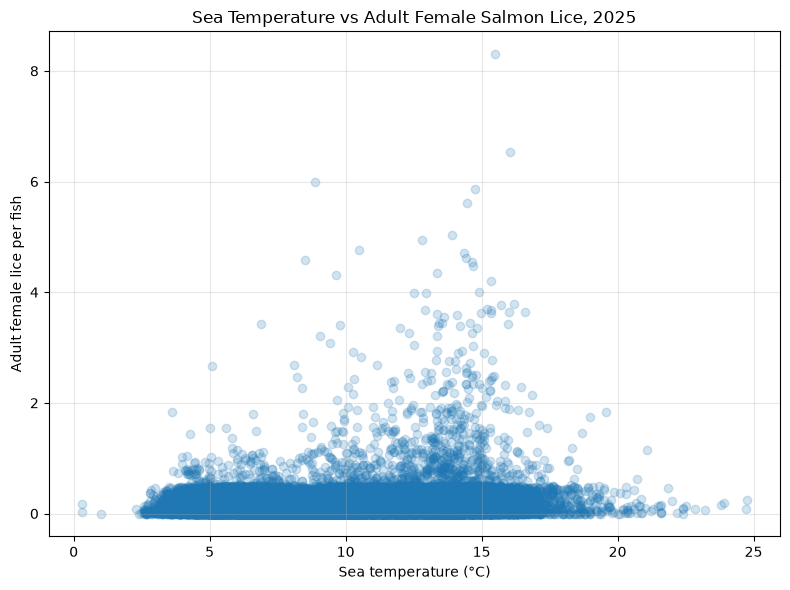

In [19]:
# look at the actual data
# Correlation gives us one number, but now we need to see the relationship.
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    temp_lice_clean["sea_temperature_c"],
    temp_lice_clean["adult_female_lice"],
    alpha=0.2
)

plt.xlabel("Sea temperature (°C)")
plt.ylabel("Adult female lice per fish")
plt.title("Sea Temperature vs Adult Female Salmon Lice, 2025")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    "../outputs/figures/day4_temperature_vs_lice.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# Lice abundance may vary non-linearly across temperature, 
* with higher values appearing more often in an intermediate temperature range rather than continuously increasing with temperature.

In [23]:
# Create temperature group
# first make 5C temperature bins.
temp_lice_clean["temperature_groups"] = pd.cut(temp_lice_clean["sea_temperature_c"], bins=[0, 5, 10, 15, 20, 25], labels=["0-5", "5-10", "10-15", "15-20", "20-25"],     include_lowest=True)
temp_lice_clean["temperature_groups"].value_counts().sort_index()

temperature_groups
0-5       2710
5-10     14085
10-15    11419
15-20     2011
20-25       47
Name: count, dtype: int64

In [24]:
# What is the typical adult female lice level in each temperature range?
grouped = temp_lice_clean.groupby("temperature_groups")

lice_by_temperature = grouped["adult_female_lice"].agg(["count", "mean", "median"])

lice_by_temperature


,count,mean,median
temperature_groups,,,
0-5,2710,0.145605,0.10
5-10,14085,0.141534,0.09
10-15,11419,0.215471,0.13
15-20,2011,0.254853,0.15
20-25,47,0.156809,0.09


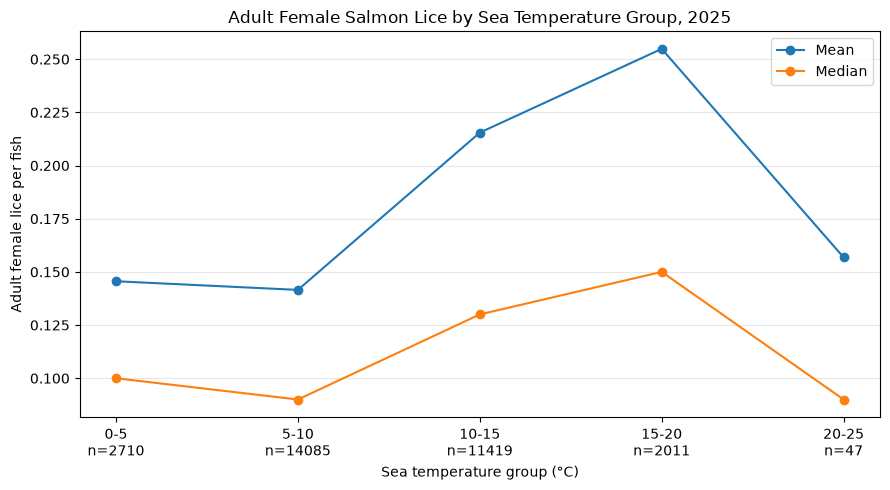

In [26]:
import matplotlib.pyplot as plt

groups = lice_by_temperature.index.astype(str)

plt.figure(figsize=(9, 5))

plt.plot(
    groups,
    lice_by_temperature["mean"],
    marker="o",
    label="Mean"
)

plt.plot(
    groups,
    lice_by_temperature["median"],
    marker="o",
    label="Median"
)

plt.xlabel("Sea temperature group (°C)")
plt.ylabel("Adult female lice per fish")
plt.title("Adult Female Salmon Lice by Sea Temperature Group, 2025")
labels = [
    "0-5\nn=2710",
    "5-10\nn=14085",
    "10-15\nn=11419",
    "15-20\nn=2011",
    "20-25\nn=47"
]

plt.xticks(
    range(len(labels)),
    labels
)

plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../outputs/figures/day4_lice_by_temperature_group.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 900x500 with 0 Axes>

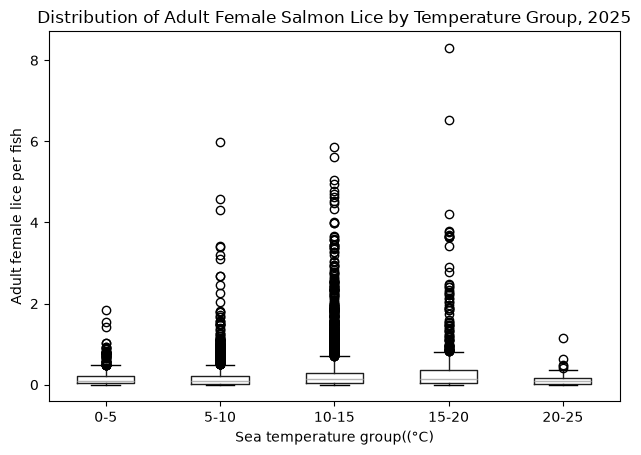

In [29]:
# boxplot so you can see the spread, median, and outliers within each temperature group.
import matplotlib.pyplot  as plt
 
plt.figure(figsize=(9,5))

temp_lice_clean.boxplot(
    column="adult_female_lice",
    by="temperature_groups",
    grid=False
)

plt.xlabel("Sea temperature group((°C)")
plt.ylabel("Adult female lice per fish")
plt.title("Distribution of Adult Female Salmon Lice by Temperature Group, 2025")
plt.suptitle("")
plt.tight_layout()


plt.savefig(
    "../outputs/figures/day4_lice_temperature_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 900x500 with 0 Axes>

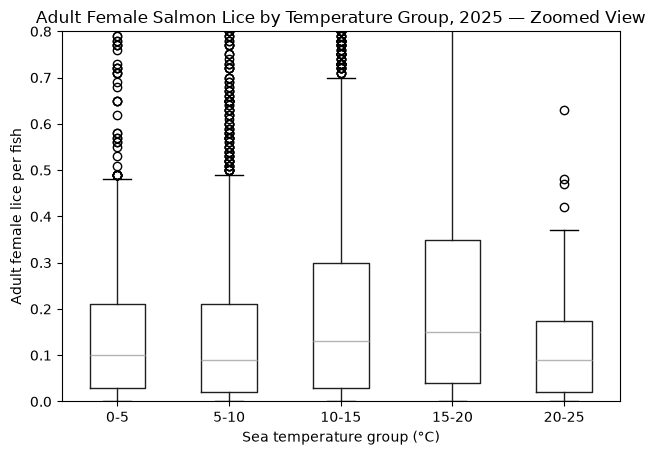

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

temp_lice_clean.boxplot(
    column="adult_female_lice",
    by="temperature_groups",
    grid=False
)

plt.ylim(0, 0.8)

plt.xlabel("Sea temperature group (°C)")
plt.ylabel("Adult female lice per fish")
plt.title("Adult Female Salmon Lice by Temperature Group, 2025 — Zoomed View")
plt.suptitle("")

plt.tight_layout()

plt.savefig(
    "../outputs/figures/day4_lice_temperature_boxplot_zoomed.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# * Adult female lice levels were generally higher and more variable in the 10–20 °C range than at lower temperatures. 
* However, the overall association with temperature remained weak, and the 20–25 °C group had very few observations.

In [31]:
df.columns.tolist()

['week',
 'year',
 'locality_id',
 'locality_name',
 'adult_female_lice',
 'mobile_lice',
 'sessile_lice',
 'probably_without_fish',
 'lice_counted',
 'municipality_id',
 'municipality',
 'county_id',
 'county',
 'latitude',
 'longitude',
 'weekly_lice_limit',
 'above_weekly_lice_limit',
 'sea_temperature_c',
 'production_area_id',
 'production_area',
 'weekly_lice_limit_numeric',
 'compliance_code']